# LSG50 Index – Pipeline Construction

This notebook builds and persists the LSG50 index using:

- S&P 500 universe
- Net income CAGR (5Y)
- Market capitalization percentile
- Composite CFO Index
- SQLite persistence layer

This notebook is executable top-to-bottom.

In [18]:
#Import and Config

# Core
import pandas as pd
import requests
from sqlalchemy import create_engine, text
from datetime import date
import sys
sys.path.append("../src")

from fundamentals import fetch_fundamentals

# Config
DB_PATH = "sqlite:///lsg50.db"
TOP_N = 50

engine = create_engine(DB_PATH)
today = str(date.today())

print("Pipeline date:", today)

Pipeline date: 2026-03-04


## 1. Database Schema Initialization

Create required tables if they do not exist.

In [19]:
with engine.connect() as conn:

    conn.execute(text("""
    CREATE TABLE IF NOT EXISTS universe (
        symbol TEXT PRIMARY KEY,
        name TEXT,
        sector TEXT
    );
    """))

    conn.execute(text("""
    CREATE TABLE IF NOT EXISTS fundamentals_snapshot (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        symbol TEXT,
        calculation_date TEXT,
        market_cap REAL,
        net_income_cagr_5y REAL,
        growth_pct REAL,
        size_pct REAL,
        cfo_index REAL,
        FOREIGN KEY(symbol) REFERENCES universe(symbol)
    );
    """))

    conn.execute(text("""
    CREATE TABLE IF NOT EXISTS lsg50_composition (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        symbol TEXT,
        calculation_date TEXT,
        weight REAL,
        cfo_index REAL,
        FOREIGN KEY(symbol) REFERENCES universe(symbol)
    );
    """))

print("Schema ready.")

Schema ready.


## 2. Build S&P 500 Universe

In [20]:
def build_universe():

    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "Mozilla/5.0"}

    response = requests.get(url, headers=headers)
    df_sp500 = pd.read_html(response.text)[0]

    df_sp500["symbol"] = (
        df_sp500["Symbol"]
        .str.replace(".", "-", regex=False)
        .str.strip()
    )

    df_universe = df_sp500[["symbol", "Security", "GICS Sector"]].rename(
        columns={
            "Security": "name",
            "GICS Sector": "sector"
        }
    )

    return df_universe

df_universe = build_universe()
df_universe.to_sql("universe", engine, if_exists="replace", index=False)

print("Universe stored:", len(df_universe), "companies")

Universe stored: 503 companies


/var/folders/qz/lqkm42d57sxb3jcp56ssgksm0000gn/T/ipykernel_4977/840134309.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_sp500 = pd.read_html(response.text)[0]


## 3. Fundamental Metrics Calculation

In [21]:
def compute_percentiles(df):

    df["growth_pct"] = df["net_income_cagr_5y"].rank(pct=True)
    df["size_pct"] = df["market_cap"].rank(pct=True)

    df["cfo_index"] = 0.5 * df["growth_pct"] + 0.5 * df["size_pct"]

    return df

symbols = df_universe["symbol"].tolist()

results = []

for s in symbols:
    data = fetch_fundamentals(s)
    if data is not None:
        results.append(data)

df_master = pd.DataFrame(results)

df_master = compute_percentiles(df_master)

df_master["calculation_date"] = today

cols = [
    "symbol",
    "calculation_date",
    "market_cap",
    "net_income_cagr_5y",
    "growth_pct",
    "size_pct",
    "cfo_index"
]

df_master[cols].to_sql(
    "fundamentals_snapshot",
    engine,
    if_exists="append",
    index=False
)

print("Fundamental snapshot stored:", len(df_master))

Fundamental snapshot stored: 443


## 4. LSG50 Index Construction

This section builds the **LSG50 Index**, a proprietary index constructed from the top 50 companies ranked by the CFO Index score.

Methodology:
- Rank companies by `cfo_index`
- Select top 50 constituents
- Assign weights proportional to their CFO score
- Store index composition in the database

In [22]:
TOP_N = 50

df_index = (
    df_master
    .sort_values("cfo_index", ascending=False)
    .head(TOP_N)
    .copy()
)

print("Selected constituents:", len(df_index))
df_index[["symbol", "cfo_index"]].head()

Selected constituents: 50


,symbol,cfo_index
302,NVDA,0.998871
178,GE,0.969526
252,LLY,0.957111
272,META,0.946953
379,TMUS,0.936795


### 4.2 Weight Allocation

Instead of equal weighting or market-cap weighting (like the S&P 500),  
the LSG50 assigns weights proportionally to the CFO Index score.

This reinforces the proprietary ranking methodology and creates
a differentiated index construction approach.

In [23]:
df_index["weight"] = df_index["cfo_index"] / df_index["cfo_index"].sum()

print("Weight sum check:", df_index["weight"].sum())
df_index[["symbol", "cfo_index", "weight"]].head()

Weight sum check: 1.0


,symbol,cfo_index,weight
302,NVDA,0.998871,0.023263
178,GE,0.969526,0.022579
252,LLY,0.957111,0.022290
272,META,0.946953,0.022053
379,TMUS,0.936795,0.021817


### 4.3 Sector Exposure (Sanity Check)

We analyze sector concentration to understand structural biases
relative to the broader S&P universe.

In [24]:
df_index = df_index.merge(
    df_universe[["symbol", "sector"]],
    on="symbol",
    how="left"
)

df_index["sector"].value_counts(normalize=True)

sector
Information Technology    0.20
Financials                0.18
Industrials               0.14
Communication Services    0.14
Health Care               0.12
Consumer Staples          0.08
Real Estate               0.06
Consumer Discretionary    0.04
Materials                 0.02
Utilities                 0.02
Name: proportion, dtype: float64

### 4.4 Persist Index Composition

The final index composition is stored in the database,
including calculation date and assigned weights.

In [25]:
df_index["calculation_date"] = today

df_index[["symbol", "calculation_date", "weight", "cfo_index"]].to_sql(
    "lsg50_composition",
    engine,
    if_exists="append",
    index=False
)

print("LSG50 composition stored:", len(df_index))

LSG50 composition stored: 50


In [26]:
df_index["weight"].sum()

np.float64(1.0)

---

## LSG50 Construction Complete

The index has been successfully constructed and persisted.

Key characteristics:
- Top 50 by proprietary CFO Index
- Score-weighted allocation
- Snapshot stored for historical tracking

In [27]:
#Verificación de tablas existentes
import pandas as pd

pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", engine)

,name
0,sp500_universe
1,fundamentals
2,lsg50_index
3,fundamentals_snapshot
4,sqlite_sequence
5,lsg50_composition
6,universe


In [28]:
#Últimos fundamentals guardados
pd.read_sql("""
SELECT *
FROM fundamentals_snapshot
ORDER BY calculation_date DESC
LIMIT 10
""", engine)

,id,symbol,calculation_date,market_cap,net_income_cagr_5y,growth_pct,size_pct,cfo_index
0,1739,MMM,2026-03-04,8.347142e+10,-0.174481,0.155756,0.713318,0.434537
1,1740,AOS,2026-03-04,1.045887e+10,0.323317,0.880361,0.040632,0.460497
2,1741,ABT,2026-03-04,1.974182e+11,-0.020064,0.329571,0.893905,0.611738
3,1742,ABBV,2026-03-04,4.135040e+11,-0.290572,0.069977,0.954853,0.512415
4,1743,ACN,2026-03-04,1.301610e+11,0.037419,0.483070,0.819413,0.651242
5,1744,ADBE,2026-03-04,1.134364e+11,0.144500,0.708804,0.785553,0.747178
6,1745,AMD,2026-03-04,3.113270e+11,0.486409,0.934537,0.934537,0.934537
7,1746,AFL,2026-03-04,5.892613e+10,0.087590,0.598194,0.604966,0.601580
8,1747,A,2026-03-04,3.374771e+10,0.012859,0.419865,0.424379,0.422122
9,1748,ABNB,2026-03-04,7.975934e+10,0.098750,0.623025,0.688488,0.655756


In [29]:
#Composición del índice 
pd.read_sql("""
SELECT *
FROM lsg50_composition
ORDER BY weight DESC
LIMIT 10
""", engine)

,id,symbol,calculation_date,weight,cfo_index
0,151,NVDA,2026-03-03,0.023281,0.998874
1,101,NVDA,2026-03-03,0.023278,0.998874
2,201,NVDA,2026-03-04,0.023263,0.998871
3,251,NVDA,2026-03-04,0.023263,0.998871
4,152,GE,2026-03-03,0.022598,0.969595
5,102,GE,2026-03-03,0.022596,0.969595
6,202,GE,2026-03-04,0.022579,0.969526
7,252,GE,2026-03-04,0.022579,0.969526
8,203,LLY,2026-03-04,0.022290,0.957111
9,253,LLY,2026-03-04,0.022290,0.957111


In [30]:
pd.read_sql("""
SELECT COUNT(*) as n_constituents
FROM lsg50_composition
""", engine)

,n_constituents
0,300


In [31]:
df_current = pd.read_sql("""
SELECT *
FROM lsg50_composition
WHERE calculation_date = (
    SELECT MAX(calculation_date)
    FROM lsg50_composition
)
""", engine)

df_current.head()

,id,symbol,calculation_date,weight,cfo_index
0,201,NVDA,2026-03-04,0.023263,0.998871
1,202,GE,2026-03-04,0.022579,0.969526
2,203,LLY,2026-03-04,0.022290,0.957111
3,204,META,2026-03-04,0.022053,0.946953
4,205,TMUS,2026-03-04,0.021817,0.936795


In [32]:
df_current.sort_values("weight", ascending=False).head(10)

,id,symbol,calculation_date,weight,cfo_index
0,201,NVDA,2026-03-04,0.023263,0.998871
50,251,NVDA,2026-03-04,0.023263,0.998871
51,252,GE,2026-03-04,0.022579,0.969526
1,202,GE,2026-03-04,0.022579,0.969526
52,253,LLY,2026-03-04,0.022290,0.957111
2,203,LLY,2026-03-04,0.022290,0.957111
53,254,META,2026-03-04,0.022053,0.946953
3,204,META,2026-03-04,0.022053,0.946953
54,255,TMUS,2026-03-04,0.021817,0.936795
4,205,TMUS,2026-03-04,0.021817,0.936795


In [33]:
top10_weight = (
    df_current
    .sort_values("weight", ascending=False)
    .head(10)["weight"]
    .sum()
)

top10_weight

np.float64(0.22400378509094732)

Este índice se desconcentra en relación al S&P500, donde las 10 empresas más grandes suponen el 30-35% del mismo vs un 22% del propio.

In [36]:
#Concentración real del índice para medir la diversificación
import numpy as np

herfindahl = np.sum(df_current["weight"] ** 2)

herfindahl

np.float64(0.04016784070342669)

In [37]:
df_current = pd.read_sql("""
SELECT *
FROM lsg50_composition
WHERE calculation_date = (
    SELECT MAX(calculation_date)
    FROM lsg50_composition
)
""", engine)

df_current = df_current.drop_duplicates(subset=["symbol"])

In [38]:
len(df_current)

50

Se observa un predominio de empresas vinculadas con TICS, financieras, industriales y de salud.

In [41]:
#Creamos dataset de donde obtendremos el índice

df_index_final = (
    df_current
    .merge(df_universe[["symbol", "sector"]], on="symbol", how="left")
    [["symbol", "sector", "cfo_index", "weight", "calculation_date"]]
)

df_index_final.head()

,symbol,sector,cfo_index,weight,calculation_date
0,NVDA,Information Technology,0.998871,0.023263,2026-03-04
1,GE,Industrials,0.969526,0.022579,2026-03-04
2,LLY,Health Care,0.957111,0.022290,2026-03-04
3,META,Communication Services,0.946953,0.022053,2026-03-04
4,TMUS,Communication Services,0.936795,0.021817,2026-03-04


In [42]:
df_index_final.to_sql(
    "lsg50_index_members",
    engine,
    if_exists="append",
    index=False
)

print("LSG50 index members stored:", len(df_index_final))

LSG50 index members stored: 50


In [43]:
pd.read_sql("""
SELECT *
FROM lsg50_index_members
ORDER BY weight DESC
LIMIT 10
""", engine)

,symbol,sector,cfo_index,weight,calculation_date
0,NVDA,Information Technology,0.998871,0.023263,2026-03-04
1,GE,Industrials,0.969526,0.022579,2026-03-04
2,LLY,Health Care,0.957111,0.022290,2026-03-04
3,META,Communication Services,0.946953,0.022053,2026-03-04
4,TMUS,Communication Services,0.936795,0.021817,2026-03-04
5,AMD,Information Technology,0.934537,0.021764,2026-03-04
6,GOOGL,Communication Services,0.931716,0.021699,2026-03-04
7,GOOG,Communication Services,0.930587,0.021672,2026-03-04
8,CRM,Information Technology,0.923251,0.021501,2026-03-04
9,NFLX,Communication Services,0.922122,0.021475,2026-03-04


In [44]:
pd.read_sql("""
SELECT 
calculation_date,
COUNT(*) as n_constituents,
SUM(weight) as total_weight
FROM lsg50_index_members
GROUP BY calculation_date
ORDER BY calculation_date DESC
""", engine)

,calculation_date,n_constituents,total_weight
0,2026-03-04,50,1.0


# 5. LSG50 Portfolio Analysis

This section analyzes the structure of the LSG50 Index.

We examine:

- Top constituents by weight
- Sector allocation
- Weight distribution

This helps evaluate diversification and structural exposures relative to the broader S&P 500 universe.

## 5.1 Top Holdings

We start by examining the largest constituents of the index.

In [45]:
top10 = (
    df_current
    .sort_values("weight", ascending=False)
    .head(10)
)

top10[["symbol", "weight", "cfo_index"]]

,symbol,weight,cfo_index
0,NVDA,0.023263,0.998871
1,GE,0.022579,0.969526
2,LLY,0.022290,0.957111
3,META,0.022053,0.946953
4,TMUS,0.021817,0.936795
5,AMD,0.021764,0.934537
6,GOOGL,0.021699,0.931716
7,GOOG,0.021672,0.930587
8,CRM,0.021501,0.923251
9,NFLX,0.021475,0.922122


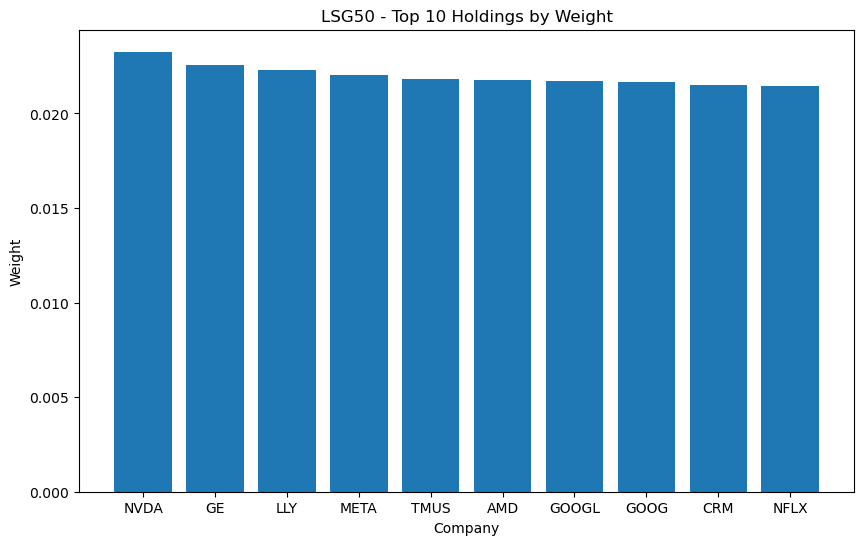

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    top10["symbol"],
    top10["weight"]
)

plt.title("LSG50 - Top 10 Holdings by Weight")
plt.xlabel("Company")
plt.ylabel("Weight")

plt.show()

## 5.2 Sector Allocation

We analyze sector exposure to understand structural biases of the index.

In [50]:
sector_weights

sector
Information Technology    0.207602
Financials                0.173431
Communication Services    0.150168
Industrials               0.136053
Health Care               0.121727
Consumer Staples          0.077384
Real Estate               0.057775
Consumer Discretionary    0.037062
Materials                 0.019530
Utilities                 0.019267
Name: weight, dtype: float64

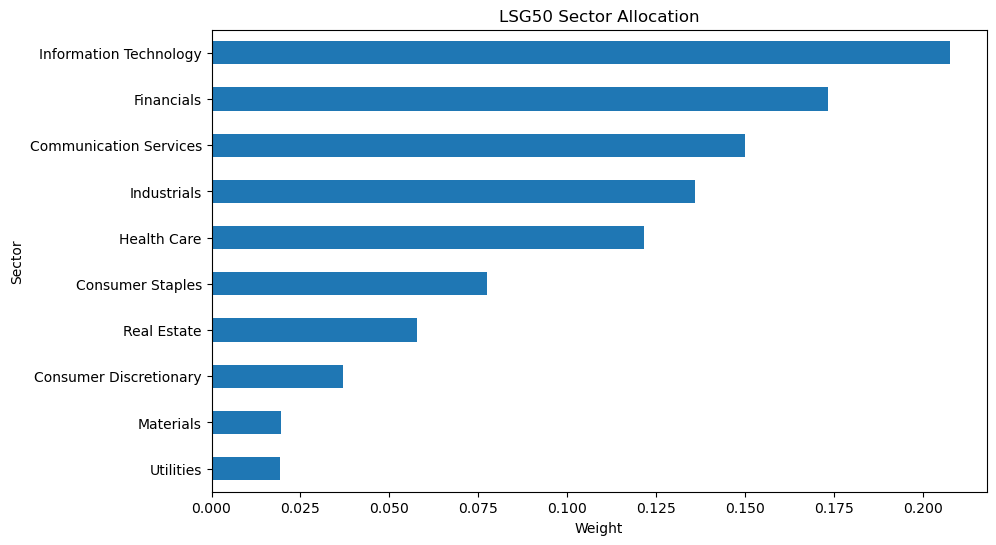

In [48]:
plt.figure(figsize=(10,6))

sector_weights.sort_values().plot(
    kind="barh"
)

plt.title("LSG50 Sector Allocation")
plt.xlabel("Weight")
plt.ylabel("Sector")

plt.show()

## 5.3 Weight Distribution

We analyze how weights are distributed across constituents.

A tighter distribution indicates stronger diversification and lower concentration risk.

In [49]:
df_current["weight"].describe()

count    50.000000
mean      0.020000
std       0.001309
min       0.018137
25%       0.018965
50%       0.019793
75%       0.021074
max       0.023263
Name: weight, dtype: float64

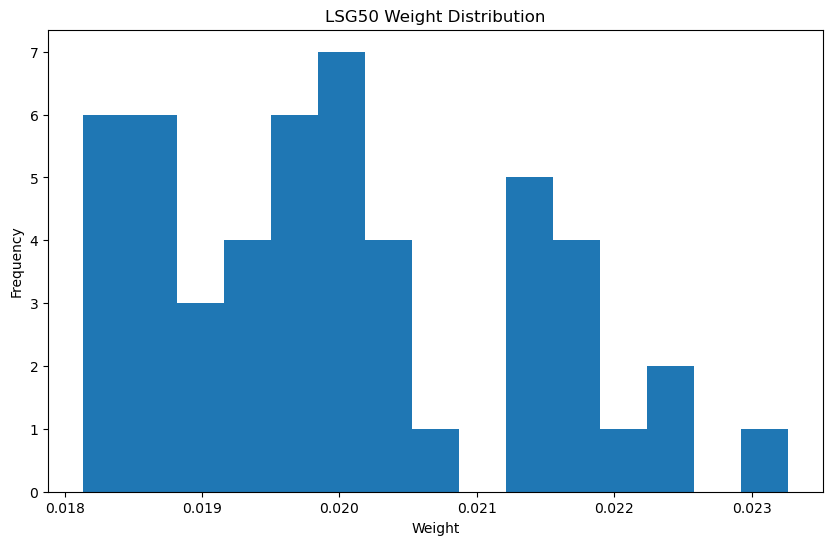

In [51]:
plt.figure(figsize=(10,6))

plt.hist(
    df_current["weight"],
    bins=15
)

plt.title("LSG50 Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")

plt.show()

## Portfolio Insights

The LSG50 index shows a relatively balanced weight distribution.

Key observations:

- The top 10 holdings represent roughly ~22% of the index.
- Sector exposure remains diversified across multiple industries.
- Weight dispersion is relatively tight, indicating low concentration risk.

Compared to the S&P 500, where the top holdings dominate a larger share of the index, the LSG50 demonstrates stronger diversification driven by its factor-based weighting methodology.